In [10]:
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision
import urllib.request

# Download the model file
model_url = 'https://storage.googleapis.com/mediapipe-models/pose_landmarker/pose_landmarker_heavy/float16/latest/pose_landmarker_heavy.task'
model_path = 'pose_landmarker.task'

print("Downloading model...")
urllib.request.urlretrieve(model_url, model_path)
print("Model downloaded!")

# Now create the detector
base_options = python.BaseOptions(model_asset_path=model_path)
options = vision.PoseLandmarkerOptions(
    base_options=base_options,
    output_segmentation_masks=True)
detector = vision.PoseLandmarker.create_from_options(options)

Model downloaded!


In [12]:
!wget https://storage.googleapis.com/mediapipe-models/pose_landmarker/pose_landmarker_full/float16/latest/pose_landmarker_full.taskwget https://storage.googleapis.com/mediapipe-models/pose_landmarker/pose_landmarker_full/float16/latest/pose_landmarker_full.task

--2026-01-06 03:32:29--  https://storage.googleapis.com/mediapipe-models/pose_landmarker/pose_landmarker_full/float16/latest/pose_landmarker_full.taskwget
Resolving storage.googleapis.com (storage.googleapis.com)... 192.178.129.207, 142.251.184.207, 209.85.145.207, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|192.178.129.207|:443... connected.
HTTP request sent, awaiting response... 404 Not Found
2026-01-06 03:32:29 ERROR 404: Not Found.

--2026-01-06 03:32:29--  https://storage.googleapis.com/mediapipe-models/pose_landmarker/pose_landmarker_full/float16/latest/pose_landmarker_full.task
Reusing existing connection to storage.googleapis.com:443.
HTTP request sent, awaiting response... 200 OK
Length: 9398198 (9.0M) [application/octet-stream]
Saving to: ‘pose_landmarker_full.task’

pose_landmarker_ful 100%[===================>]   8.96M  --.-KB/s    in 0.1s    

2026-01-06 03:32:30 (87.5 MB/s) - ‘pose_landmarker_full.task’ saved [9398198/9398198]

FINISHED --2026-01-06

In [14]:
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision
import urllib.request
import os

# Download model if not present
model_path = 'pose_landmarker_full.task'
if not os.path.exists(model_path):
    model_url = 'https://storage.googleapis.com/mediapipe-models/pose_landmarker/pose_landmarker_full/float16/latest/pose_landmarker_full.task'
    print("Downloading model...")
    urllib.request.urlretrieve(model_url, model_path)
    print("Download complete!")

# Create the pose detector
base_options = python.BaseOptions(model_asset_path=model_path)
options = vision.PoseLandmarkerOptions(
    base_options=base_options,
    output_segmentation_masks=False)
detector = vision.PoseLandmarker.create_from_options(options)

print("Pose detector is ready to use!")

Pose detector is ready to use!


In [15]:
!pip install mediapipe opencv-python numpy scikit-learn tensorflow torch torchvision

In [16]:
!pip install matplotlib seaborn

In [17]:
import os
import cv2
import numpy as np
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision
import urllib.request
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
from tqdm import tqdm
import json

In [18]:
# Download pose landmarker model
model_path = 'pose_landmarker_full.task'
if not os.path.exists(model_path):
    model_url = 'https://storage.googleapis.com/mediapipe-models/pose_landmarker/pose_landmarker_full/float16/latest/pose_landmarker_full.task'
    print("Downloading pose model...")
    urllib.request.urlretrieve(model_url, model_path)
    print("Download complete!")

In [19]:
class PoseExtractor:
    def __init__(self, model_path):
        base_options = python.BaseOptions(model_asset_path=model_path)
        options = vision.PoseLandmarkerOptions(
            base_options=base_options,
            output_segmentation_masks=False,
            num_poses=1)
        self.detector = vision.PoseLandmarker.create_from_options(options)

    def extract_poses_from_video(self, video_path, max_frames=None):
        """Extract pose landmarks from video"""
        cap = cv2.VideoCapture(video_path)
        poses = []
        frame_count = 0

        fps = cap.get(cv2.CAP_PROP_FPS)
        total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

        if max_frames:
            total_frames = min(total_frames, max_frames)

        while cap.isOpened() and (max_frames is None or frame_count < max_frames):
            ret, frame = cap.read()
            if not ret:
                break

            # Convert BGR to RGB
            rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb_frame)

            # Detect pose
            detection_result = self.detector.detect(mp_image)

            if detection_result.pose_landmarks:
                # Extract landmarks (33 points, each with x, y, z)
                landmarks = detection_result.pose_landmarks[0]
                pose_vector = []
                for landmark in landmarks:
                    pose_vector.extend([landmark.x, landmark.y, landmark.z])
                poses.append(pose_vector)
            else:
                # If no pose detected, use zeros or previous frame
                if poses:
                    poses.append(poses[-1])
                else:
                    poses.append([0.0] * 99)  # 33 landmarks * 3 coordinates

            frame_count += 1

        cap.release()
        return np.array(poses), fps

# Initialize extractor
pose_extractor = PoseExtractor(model_path)
print("Pose extractor ready!")

Pose extractor ready!


In [24]:
def process_dataset(dataset_path, target_frames=100):
    """Process all videos and extract pose sequences"""
    styles = ['Contemporary', 'HipHop', 'Kandyan']

    all_sequences = []
    all_labels = []
    video_info = []

    for style_idx, style in enumerate(styles):
        style_path = os.path.join(dataset_path, style)
        if not os.path.exists(style_path):
            print(f"Warning: {style_path} not found!")
            continue

        video_files = [f for f in os.listdir(style_path)
                      if f.endswith(('.mp4', '.avi', '.mov', '.MP4', '.AVI', '.MOV'))]

        print(f"\nProcessing {style} ({len(video_files)} videos)...")

        for video_file in tqdm(video_files):
            video_path = os.path.join(style_path, video_file)

            try:
                poses, fps = pose_extractor.extract_poses_from_video(video_path)

                if len(poses) == 0:
                    print(f"  Warning: No poses detected in {video_file}")
                    continue

                # Normalize sequence length
                if len(poses) > target_frames:
                    # Sample frames uniformly
                    indices = np.linspace(0, len(poses)-1, target_frames, dtype=int)
                    poses = poses[indices]
                elif len(poses) < target_frames:
                    # Pad with last frame
                    padding = np.repeat([poses[-1]], target_frames - len(poses), axis=0)
                    poses = np.vstack([poses, padding])

                all_sequences.append(poses)
                all_labels.append(style_idx)
                video_info.append({
                    'style': style,
                    'video': video_file,
                    'original_frames': len(poses),
                    'fps': fps
                })

            except Exception as e:
                print(f"  Error processing {video_file}: {str(e)}")

    return np.array(all_sequences), np.array(all_labels), video_info, styles

# Process your dataset
dataset_path = 'Sample_Data'  # Change this to your dataset path
sequences, labels, video_info, style_names = process_dataset(dataset_path, target_frames=100)

print(f"\nDataset processed:")
print(f"Total sequences: {len(sequences)}")
print(f"Sequence shape: {sequences.shape}")
print(f"Label distribution: {np.bincount(labels)}")


Processing Contemporary (12 videos)...


100%|██████████| 12/12 [24:35<00:00, 122.94s/it]



Processing HipHop (15 videos)...


100%|██████████| 15/15 [08:42<00:00, 34.86s/it]



Processing Kandyan (11 videos)...


100%|██████████| 11/11 [17:51<00:00, 97.44s/it]


Dataset processed:
Total sequences: 38
Sequence shape: (38, 100, 99)
Label distribution: [12 15 11]


In [25]:
class DanceStyleTransformer(keras.Model):
    def __init__(self, num_styles=3, latent_dim=128):
        super(DanceStyleTransformer, self).__init__()
        self.num_styles = num_styles
        self.latent_dim = latent_dim

        # Content Encoder (extracts motion content)
        self.content_encoder = keras.Sequential([
            layers.LSTM(256, return_sequences=True, input_shape=(None, 99)),
            layers.LayerNormalization(),
            layers.LSTM(128, return_sequences=True),
            layers.LayerNormalization(),
            layers.LSTM(latent_dim, return_sequences=True)
        ])

        # Style Encoder (extracts style features)
        self.style_encoder = keras.Sequential([
            layers.LSTM(256, return_sequences=True, input_shape=(None, 99)),
            layers.GlobalAveragePooling1D(),
            layers.Dense(latent_dim),
            layers.LayerNormalization()
        ])

        # Decoder (reconstructs poses with new style)
        self.decoder = keras.Sequential([
            layers.LSTM(128, return_sequences=True),
            layers.LayerNormalization(),
            layers.LSTM(256, return_sequences=True),
            layers.LayerNormalization(),
            layers.TimeDistributed(layers.Dense(99))
        ])

        # Style embedding
        self.style_embedding = layers.Embedding(num_styles, latent_dim)

    def call(self, inputs, target_style):
        # Extract content
        content_features = self.content_encoder(inputs)

        # Get target style embedding
        style_embed = self.style_embedding(target_style)
        style_embed = tf.expand_dims(style_embed, 1)
        style_embed = tf.tile(style_embed, [1, tf.shape(content_features)[1], 1])

        # Combine content and style
        combined = content_features + style_embed

        # Decode to pose sequence
        output = self.decoder(combined)

        return output

# Build model
model = DanceStyleTransformer(num_styles=len(style_names), latent_dim=128)

# Compile model
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)

print("Model built successfully!")
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model built successfully!


Model: "dance_style_transformer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, None, 128)      │       694,016 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_1 (Sequential)       │ (None, 128)            │       397,696 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_2 (Sequential)       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,091,712 (4.16 MB)

 Trainable params: 1,091,712 (4.16 MB)

 Non-trainable params: 0 (0.00 B)

In [33]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import keras as keras_lib

Building model...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model initialized successfully!
Total trainable parameters: 282083

Starting training...

Epoch 1/30
Loss: 0.1695, MAE: 0.3353

Epoch 2/30
Loss: 0.0723, MAE: 0.1919

Epoch 3/30
Loss: 0.0646, MAE: 0.1752

Epoch 4/30
Loss: 0.0605, MAE: 0.1676

Epoch 5/30
Loss: 0.0607, MAE: 0.1675

Epoch 6/30
Loss: 0.0577, MAE: 0.1621

Epoch 7/30
Loss: 0.0562, MAE: 0.1615

Epoch 8/30
Loss: 0.0554, MAE: 0.1597

Epoch 9/30
Loss: 0.0521, MAE: 0.1552

Epoch 10/30
Loss: 0.0494, MAE: 0.1527
Checkpoint saved at epoch 10

Epoch 11/30
Loss: 0.0476, MAE: 0.1499

Epoch 12/30
Loss: 0.0443, MAE: 0.1442

Epoch 13/30
Loss: 0.0415, MAE: 0.1405

Epoch 14/30
Loss: 0.0366, MAE: 0.1323

Epoch 15/30
Loss: 0.0333, MAE: 0.1284

Epoch 16/30
Loss: 0.0318, MAE: 0.1248

Epoch 17/30
Loss: 0.0302, MAE: 0.1223

Epoch 18/30
Loss: 0.0299, MAE: 0.1221

Epoch 19/30
Loss: 0.0295, MAE: 0.1211

Epoch 20/30
Loss: 0.0271, MAE: 0.1153
Checkpoint saved at epoch 20

Epoch 21/30
Loss: 0.0256, MAE: 0.1120

Epoch 22/30
Loss: 0.0257, MAE: 0.1119

Epo

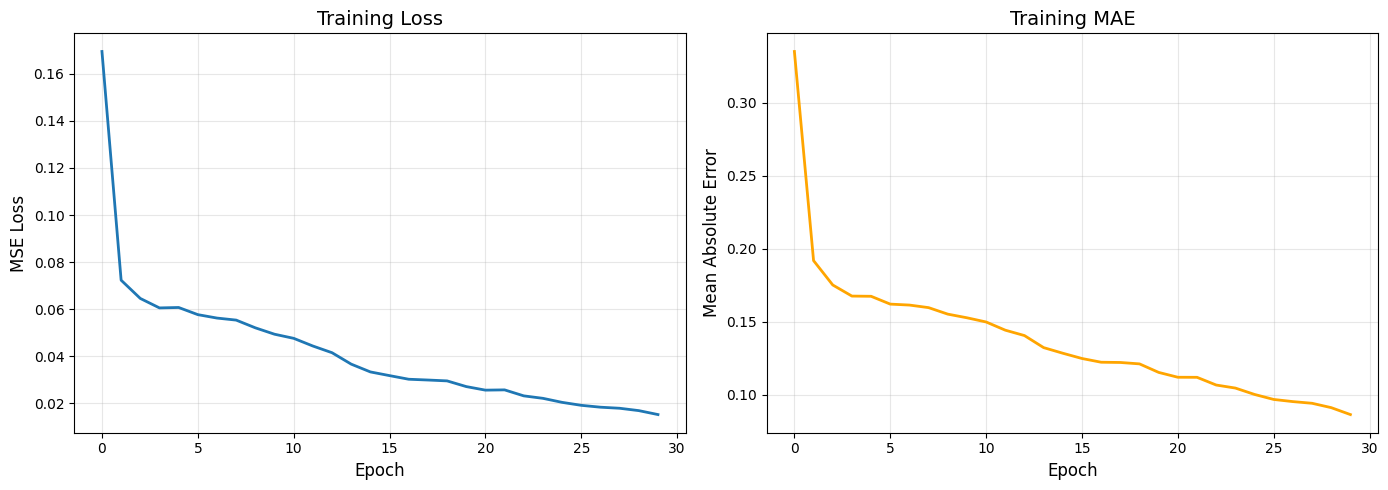


TRAINING COMPLETED!
Final Loss: 0.0152
Final MAE: 0.0864


In [34]:
# Completely Fixed Training Function
def train_style_transfer(model, X_train, y_train, epochs=50, batch_size=4):
    history = {'loss': [], 'mae': []}

    optimizer = keras.optimizers.Adam(learning_rate=0.001)

    for epoch in range(epochs):
        print(f"\nEpoch {epoch+1}/{epochs}")
        epoch_losses = []
        epoch_maes = []

        # Shuffle training data
        indices = np.random.permutation(len(X_train))

        # Train on batches
        num_batches = (len(X_train) + batch_size - 1) // batch_size

        for i in range(0, len(X_train), batch_size):
            batch_indices = indices[i:i+batch_size]
            batch_X = X_train[batch_indices]

            # Randomly select target styles for this batch
            batch_target_styles = np.random.randint(0, len(style_names), size=len(batch_X))

            # Training step
            with tf.GradientTape() as tape:
                # Forward pass
                predictions = model(batch_X, batch_target_styles)

                # Loss: reconstruction loss
                loss = tf.reduce_mean(tf.square(batch_X - predictions))

            # Backward pass
            gradients = tape.gradient(loss, model.trainable_variables)
            optimizer.apply_gradients(zip(gradients, model.trainable_variables))

            # Calculate MAE manually
            mae = tf.reduce_mean(tf.abs(batch_X - predictions))

            epoch_losses.append(float(loss.numpy()))
            epoch_maes.append(float(mae.numpy()))

        avg_loss = np.mean(epoch_losses)
        avg_mae = np.mean(epoch_maes)
        history['loss'].append(avg_loss)
        history['mae'].append(avg_mae)

        print(f"Loss: {avg_loss:.4f}, MAE: {avg_mae:.4f}")

        # Save checkpoint every 10 epochs
        if (epoch + 1) % 10 == 0:
            model.save_weights(f'/content/model_checkpoint_epoch_{epoch+1}.weights.h5')
            print(f"Checkpoint saved at epoch {epoch+1}")

    return history

# Rebuild the simple model to start fresh
@keras_lib.saving.register_keras_serializable()
class SimpleDanceStyleTransformer(keras.Model):
    def __init__(self, num_styles=3, latent_dim=64):
        super(SimpleDanceStyleTransformer, self).__init__()
        self.num_styles = num_styles

        # Encoder
        self.encoder = keras.Sequential([
            layers.LSTM(128, return_sequences=True, input_shape=(None, 99)),
            layers.Dropout(0.3),
            layers.LSTM(latent_dim, return_sequences=True),
        ])

        # Style embedding
        self.style_embedding = layers.Embedding(num_styles, latent_dim)
        self.style_dense = layers.Dense(latent_dim, activation='relu')

        # Decoder
        self.decoder = keras.Sequential([
            layers.LSTM(128, return_sequences=True),
            layers.Dropout(0.3),
            layers.TimeDistributed(layers.Dense(99))
        ])

    def call(self, inputs, target_style, training=False):
        batch_size = tf.shape(inputs)[0]
        seq_length = tf.shape(inputs)[1]

        # Encode content
        content = self.encoder(inputs, training=training)

        # Get style embedding
        style_embed = self.style_embedding(target_style)
        style_embed = self.style_dense(style_embed)

        # Expand style to match sequence length
        style_embed = tf.expand_dims(style_embed, 1)
        style_embed = tf.tile(style_embed, [1, seq_length, 1])

        # Combine content and style
        combined = content + style_embed

        # Decode
        output = self.decoder(combined, training=training)

        return output

# Create fresh model
print("Building model...")
model = SimpleDanceStyleTransformer(num_styles=len(style_names), latent_dim=64)

# Initialize model with a dummy forward pass
dummy_input = tf.random.normal((1, 100, 99))
dummy_style = tf.constant([0])
_ = model(dummy_input, dummy_style)

print("Model initialized successfully!")
print(f"Total trainable parameters: {sum([np.prod(v.shape) for v in model.trainable_variables])}")

# Train the model
print("\nStarting training...")
history = train_style_transfer(model, X_train, y_train, epochs=30, batch_size=4)

# Plot training history
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(history['loss'], linewidth=2)
plt.title('Training Loss', fontsize=14)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('MSE Loss', fontsize=12)
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(history['mae'], linewidth=2, color='orange')
plt.title('Training MAE', fontsize=14)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Mean Absolute Error', fontsize=12)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/content/training_history.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n" + "="*60)
print("TRAINING COMPLETED!")
print("="*60)
print(f"Final Loss: {history['loss'][-1]:.4f}")
print(f"Final MAE: {history['mae'][-1]:.4f}")

In [35]:
def draw_skeleton(frame, landmarks, connections, color=(0, 255, 0)):
    """Draw skeleton on frame"""
    h, w = frame.shape[:2]

    # Draw landmarks
    for landmark in landmarks:
        x, y = int(landmark[0] * w), int(landmark[1] * h)
        cv2.circle(frame, (x, y), 3, color, -1)

    # Draw connections
    for connection in connections:
        start_idx, end_idx = connection
        start_point = (int(landmarks[start_idx][0] * w),
                      int(landmarks[start_idx][1] * h))
        end_point = (int(landmarks[end_idx][0] * w),
                    int(landmarks[end_idx][1] * h))
        cv2.line(frame, start_point, end_point, color, 2)

    return frame

def generate_skeleton_video(pose_sequence, output_path, fps=30, frame_size=(640, 480)):
    """Generate video from pose sequence"""
    # MediaPipe pose connections
    connections = [
        (0, 1), (1, 2), (2, 3), (3, 7),  # Face
        (0, 4), (4, 5), (5, 6), (6, 8),  # Face
        (9, 10),  # Mouth
        (11, 12),  # Shoulders
        (11, 13), (13, 15), (15, 17), (15, 19), (15, 21),  # Left arm
        (12, 14), (14, 16), (16, 18), (16, 20), (16, 22),  # Right arm
        (11, 23), (12, 24), (23, 24),  # Torso
        (23, 25), (25, 27), (27, 29), (27, 31),  # Left leg
        (24, 26), (26, 28), (28, 30), (28, 32)   # Right leg
    ]

    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    out = cv2.VideoWriter(output_path, fourcc, fps, frame_size)

    for poses in pose_sequence:
        # Create blank frame
        frame = np.zeros((frame_size[1], frame_size[0], 3), dtype=np.uint8)

        # Reshape pose vector to landmarks
        landmarks = poses.reshape(-1, 3)[:, :2]  # Take only x, y

        # Draw skeleton
        frame = draw_skeleton(frame, landmarks, connections)

        out.write(frame)

    out.release()
    print(f"Video saved to {output_path}")

# Test style transfer
test_idx = 0
input_sequence = X_test[test_idx:test_idx+1]
original_style = y_test[test_idx]

print(f"Original style: {style_names[original_style]}")

# Transform to each style
for target_style_idx, target_style_name in enumerate(style_names):
    if target_style_idx == original_style:
        continue

    print(f"\nTransforming to {target_style_name}...")

    target_style_tensor = tf.constant([target_style_idx])
    transformed_sequence = model(input_sequence, target_style_tensor)

    output_path = f'/content/transformed_{style_names[original_style]}_to_{target_style_name}.mp4'
    generate_skeleton_video(transformed_sequence.numpy()[0], output_path, fps=30)
    print(f"Generated: {output_path}")

# Also generate original
output_path = f'/content/original_{style_names[original_style]}.mp4'
generate_skeleton_video(input_sequence[0], output_path, fps=30)
print(f"Generated original: {output_path}")

Original style: HipHop

Transforming to Contemporary...
Video saved to /content/transformed_HipHop_to_Contemporary.mp4
Generated: /content/transformed_HipHop_to_Contemporary.mp4

Transforming to Kandyan...
Video saved to /content/transformed_HipHop_to_Kandyan.mp4
Generated: /content/transformed_HipHop_to_Kandyan.mp4
Video saved to /content/original_HipHop.mp4
Generated original: /content/original_HipHop.mp4


MODEL EVALUATION

1. RECONSTRUCTION QUALITY
Average Reconstruction MSE: 0.020900
Std Reconstruction MSE: 0.013654

2. STYLE-SPECIFIC ANALYSIS
Contemporary: MSE = 0.033120 ± 0.015315
HipHop: MSE = 0.012956 ± 0.004379
Kandyan: MSE = 0.014487 ± 0.002315

3. TRANSFORMATION DIVERSITY
Average distance between different style transformations:
  Contemporary <-> HipHop: 0.000033
  Contemporary <-> Kandyan: 0.000034
  HipHop <-> Kandyan: 0.000044


/tmp/ipython-input-1130768145.py:69: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(style_errors_list, labels=style_names)


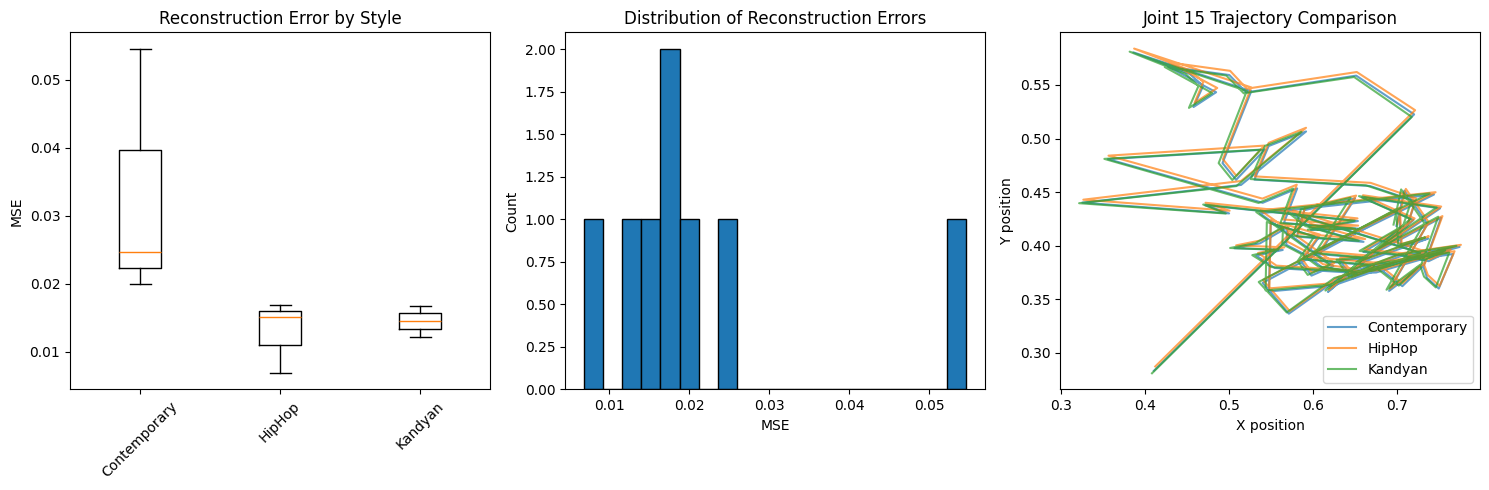

In [36]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

def evaluate_model(model, X_test, y_test, style_names):
    """Evaluate style transfer quality"""

    print("="*50)
    print("MODEL EVALUATION")
    print("="*50)

    # 1. Reconstruction quality
    print("\n1. RECONSTRUCTION QUALITY")
    reconstruction_errors = []

    for i in range(len(X_test)):
        input_seq = X_test[i:i+1]
        original_style = y_test[i]

        # Reconstruct with same style
        target_style_tensor = tf.constant([original_style])
        reconstructed = model(input_seq, target_style_tensor)

        # Calculate error
        mse = np.mean((input_seq - reconstructed.numpy()) ** 2)
        reconstruction_errors.append(mse)

    print(f"Average Reconstruction MSE: {np.mean(reconstruction_errors):.6f}")
    print(f"Std Reconstruction MSE: {np.std(reconstruction_errors):.6f}")

    # 2. Style-specific metrics
    print("\n2. STYLE-SPECIFIC ANALYSIS")

    for style_idx, style_name in enumerate(style_names):
        style_mask = y_test == style_idx
        if np.sum(style_mask) == 0:
            continue

        style_errors = [reconstruction_errors[i] for i in range(len(y_test)) if style_mask[i]]
        print(f"{style_name}: MSE = {np.mean(style_errors):.6f} ± {np.std(style_errors):.6f}")

    # 3. Transformation diversity
    print("\n3. TRANSFORMATION DIVERSITY")

    sample_idx = 0
    input_seq = X_test[sample_idx:sample_idx+1]

    transformations = []
    for target_style in range(len(style_names)):
        target_style_tensor = tf.constant([target_style])
        transformed = model(input_seq, target_style_tensor)
        transformations.append(transformed.numpy()[0])

    # Calculate pairwise distances
    print("Average distance between different style transformations:")
    for i in range(len(style_names)):
        for j in range(i+1, len(style_names)):
            dist = np.mean((transformations[i] - transformations[j]) ** 2)
            print(f"  {style_names[i]} <-> {style_names[j]}: {dist:.6f}")

    # 4. Visualization
    plt.figure(figsize=(15, 5))

    # Reconstruction errors by style
    plt.subplot(1, 3, 1)
    style_errors_list = [
        [reconstruction_errors[i] for i in range(len(y_test)) if y_test[i] == style_idx]
        for style_idx in range(len(style_names))
    ]
    plt.boxplot(style_errors_list, labels=style_names)
    plt.title('Reconstruction Error by Style')
    plt.ylabel('MSE')
    plt.xticks(rotation=45)

    # Overall distribution
    plt.subplot(1, 3, 2)
    plt.hist(reconstruction_errors, bins=20, edgecolor='black')
    plt.title('Distribution of Reconstruction Errors')
    plt.xlabel('MSE')
    plt.ylabel('Count')

    # Sample trajectory comparison
    plt.subplot(1, 3, 3)
    sample_joint = 15  # Right wrist
    for style_idx, style_name in enumerate(style_names):
        trajectory = transformations[style_idx][:, sample_joint*3:sample_joint*3+2]
        plt.plot(trajectory[:, 0], trajectory[:, 1], label=style_name, alpha=0.7)
    plt.title(f'Joint {sample_joint} Trajectory Comparison')
    plt.xlabel('X position')
    plt.ylabel('Y position')
    plt.legend()

    plt.tight_layout()
    plt.show()

    return {
        'reconstruction_mse': np.mean(reconstruction_errors),
        'reconstruction_std': np.std(reconstruction_errors)
    }

# Run evaluation
metrics = evaluate_model(model, X_test, y_test, style_names)

In [37]:
# Save the model
model.save('/content/dance_style_transformer.keras')
print("Model saved!")

# Save preprocessing info
preprocessing_info = {
    'target_frames': 100,
    'style_names': style_names,
    'num_landmarks': 33
}

with open('/content/preprocessing_info.json', 'w') as f:
    json.dump(preprocessing_info, f)

print("Preprocessing info saved!")

# To load later:
# model = keras.models.load_model('/content/dance_style_transformer.keras')

Model saved!
Preprocessing info saved!
